# Data Processing Notebook

This notebook:
1. Reads raw sources from `data/raw/` (`CS1.csv`, `CS2.csv`, `cs3.csv`, `cs4.csv`)
2. Uses `data/raw/description of variables 1.xlsx` for variable names
3. Builds quality statistics and visualizations
4. Applies cleaning: remove post-default rows, missingness flags, median imputation
5. Writes processed outputs to `data/processing/`


In [ ]:
from __future__ import annotations

import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTS = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_PLOTS = False
    print("matplotlib/seaborn not installed in the uv env. Run: uv add matplotlib seaborn")

DATA_ROOT = Path("data")
RAW_DIR = DATA_ROOT / "raw"
PROCESSING_DIR = DATA_ROOT / "processing"
LOG_DIR = DATA_ROOT / "logs"
FINAL_DIR = DATA_ROOT / "final"

CSV_FILES = ["CS1.csv", "CS2.csv", "cs3.csv", "cs4.csv"]
DESCRIPTION_FILE = RAW_DIR / "description of variables 1.xlsx"

for _dir in (RAW_DIR, PROCESSING_DIR, LOG_DIR, FINAL_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

NS = {"m": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}


In [2]:
def _load_shared_strings(workbook: zipfile.ZipFile) -> list[str]:
    root = ET.fromstring(workbook.read("xl/sharedStrings.xml"))
    shared: list[str] = []
    for si in root.findall("m:si", NS):
        text_parts = [text_node.text or "" for text_node in si.findall(".//m:t", NS)]
        shared.append("".join(text_parts))
    return shared


def _cell_value(cell: ET.Element, shared_strings: list[str]) -> str:
    cell_type = cell.attrib.get("t")
    if cell_type == "inlineStr":
        inline = cell.find("m:is/m:t", NS)
        return (inline.text or "") if inline is not None else ""

    value_node = cell.find("m:v", NS)
    if value_node is None:
        return ""

    value = value_node.text or ""
    if cell_type == "s":
        return shared_strings[int(value)]
    return value


def _read_sheet_rows(workbook: zipfile.ZipFile, sheet_path: str, shared_strings: list[str]) -> list[list[str]]:
    root = ET.fromstring(workbook.read(sheet_path))
    rows: list[list[str]] = []

    for row in root.findall(".//m:sheetData/m:row", NS):
        row_values: list[str] = []
        for cell in row.findall("m:c", NS):
            row_values.append(_cell_value(cell, shared_strings))
        rows.append(row_values)

    return rows


def read_column_descriptions(xlsx_path: Path) -> dict[str, str]:
    with zipfile.ZipFile(xlsx_path) as workbook:
        shared_strings = _load_shared_strings(workbook)
        rows = _read_sheet_rows(workbook, "xl/worksheets/sheet2.xml", shared_strings)

    mapping: dict[str, str] = {}
    for row in rows[1:]:
        if len(row) >= 2 and row[0]:
            mapping[row[0].strip()] = row[1].strip()
    return mapping


def merge_csv_files(data_dir: Path, csv_files: list[str]) -> pd.DataFrame:
    parts = [pd.read_csv(data_dir / file_name, sep=";", low_memory=False) for file_name in csv_files]
    return pd.concat(parts, ignore_index=True)


def build_unique_renamed_columns(columns: list[str], descriptions: dict[str, str]) -> dict[str, str]:
    renamed: dict[str, str] = {}
    used_names: dict[str, int] = {}

    for column in columns:
        base_name = descriptions.get(column, column)
        counter = used_names.get(base_name, 0)
        used_names[base_name] = counter + 1
        final_name = base_name if counter == 0 else f"{base_name} ({counter + 1})"
        renamed[column] = final_name

    return renamed


In [3]:
descriptions = read_column_descriptions(DESCRIPTION_FILE)
raw_df = merge_csv_files(RAW_DIR, CSV_FILES)

# Normalize placeholders and parse schema
raw_df = raw_df.replace(["NA", "", " "], np.nan)
raw_df["obs_date"] = pd.to_datetime(raw_df["obs_date"], errors="coerce")

var_cols = [c for c in raw_df.columns if c.startswith("Var_")]
numeric_candidates = ["ID", "default", *var_cols]
for col in numeric_candidates:
    if col in raw_df.columns:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df["default"] = raw_df["default"].astype("Int64")
renamed_columns = build_unique_renamed_columns(list(raw_df.columns), descriptions)

raw_df.shape


(148929, 42)

In [ ]:
merged_output = PROCESSING_DIR / "merged_all.csv"
merged_descriptive_output = PROCESSING_DIR / "merged_all_with_descriptions.csv"

raw_df.to_csv(merged_output, sep=";", index=False)
raw_df.rename(columns=renamed_columns).to_csv(merged_descriptive_output, sep=";", index=False)

print(f"Saved: {merged_output}")
print(f"Saved: {merged_descriptive_output}")


## 4. Shape, dtypes, duplicates overview

,metric,value
0,rows,148929
1,columns,42
2,duplicate full rows,0
3,"duplicate (ID, obs_date)",0
4,unique companies (ID),46069


,dtype,count
0,float64,39
1,int64,1
2,datetime64[us],1
3,Int64,1


,column,dtype
41,default,Int64
1,obs_date,datetime64[us]
2,Var_01,float64
3,Var_02,float64
4,Var_03,float64
5,Var_04,float64
6,Var_05,float64
7,Var_06,float64
8,Var_07,float64
9,Var_08,float64


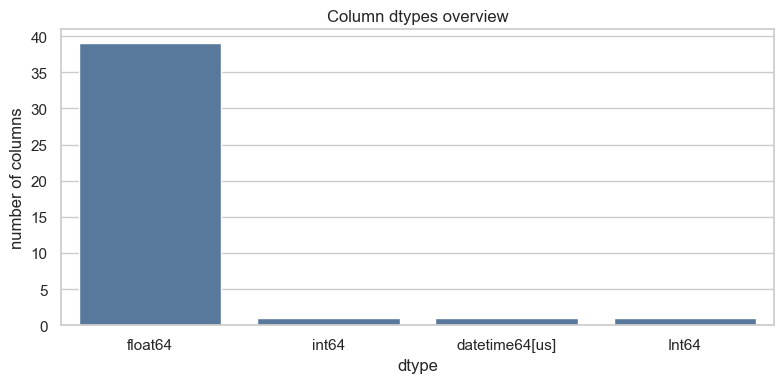

In [5]:
overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "duplicate full rows",
            "duplicate (ID, obs_date)",
            "unique companies (ID)",
        ],
        "value": [
            len(raw_df),
            raw_df.shape[1],
            int(raw_df.duplicated().sum()),
            int(raw_df.duplicated(subset=["ID", "obs_date"]).sum()),
            int(raw_df["ID"].nunique(dropna=True)),
        ],
    }
)

dtype_overview = (
    raw_df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

column_dtype = (
    pd.DataFrame({"column": raw_df.columns, "dtype": raw_df.dtypes.astype(str).values})
    .sort_values(["dtype", "column"])
)

display(overview)
display(dtype_overview)
display(column_dtype)

if HAS_PLOTS:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=dtype_overview, x="dtype", y="count", color="#4e79a7")
    plt.title("Column dtypes overview")
    plt.xlabel("dtype")
    plt.ylabel("number of columns")
    plt.tight_layout()
    plt.show()


## 5. Missing value analysis: % per variable, patterns, heatmap

,column,missing_pct,missing_count
0,Var_20,9.606591,14307
1,Var_38,8.788752,13089
2,Var_06,8.251583,12289
3,Var_28,5.248138,7816
4,Var_26,3.025603,4506
5,Var_03,2.922869,4353
6,Var_17,1.478557,2202
7,Var_05,0.945417,1408
8,Var_33,0.890357,1326
9,Var_37,0.889014,1324


,missing_columns_in_row,row_count
0,0,108499
1,1,28042
2,2,7443
3,3,2154
4,4,678
5,5,314
6,6,327
7,7,260
8,8,307
9,9,242


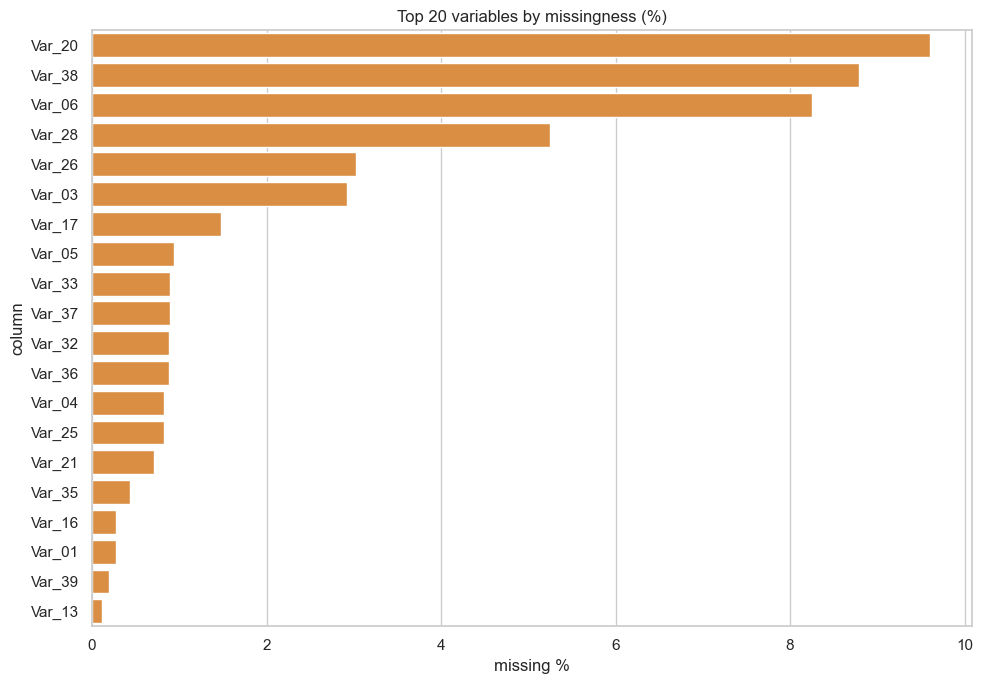

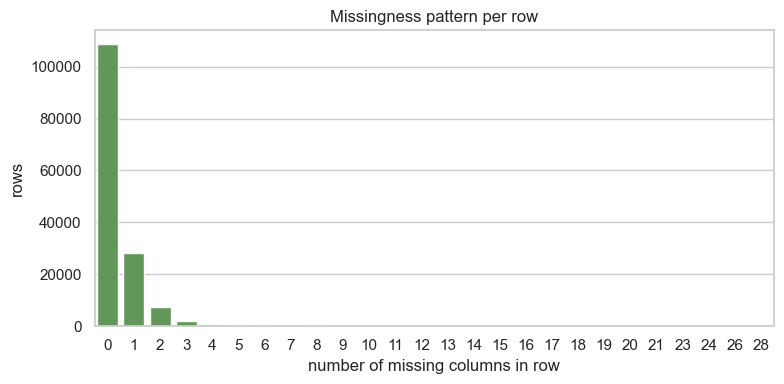

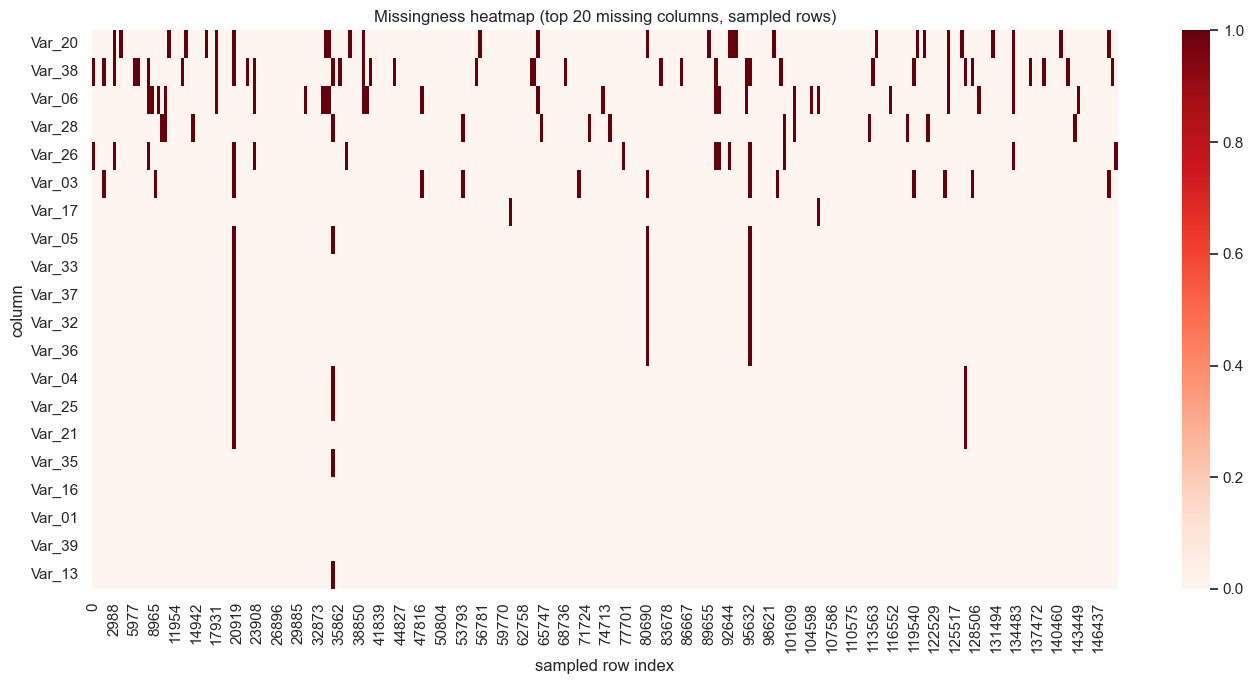

In [6]:
missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame(
    {
        "column": missing_pct.index,
        "missing_pct": missing_pct.values,
        "missing_count": raw_df.isna().sum()[missing_pct.index].values,
    }
)

display(missing_table)

missing_per_row = raw_df.isna().sum(axis=1)
missing_pattern = (
    missing_per_row.value_counts()
    .sort_index()
    .rename_axis("missing_columns_in_row")
    .reset_index(name="row_count")
)

display(missing_pattern)

if HAS_PLOTS:
    top_missing = missing_table.head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=top_missing, y="column", x="missing_pct", color="#f28e2b")
    plt.title("Top 20 variables by missingness (%)")
    plt.xlabel("missing %")
    plt.ylabel("column")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.barplot(data=missing_pattern, x="missing_columns_in_row", y="row_count", color="#59a14f")
    plt.title("Missingness pattern per row")
    plt.xlabel("number of missing columns in row")
    plt.ylabel("rows")
    plt.tight_layout()
    plt.show()

    heatmap_cols = missing_table.head(20)["column"].tolist()
    sample_n = min(300, len(raw_df))
    if sample_n > 0 and heatmap_cols:
        sample_idx = np.linspace(0, len(raw_df) - 1, num=sample_n, dtype=int)
        missing_sample = raw_df.iloc[sample_idx][heatmap_cols].isna().astype(int).T

        plt.figure(figsize=(14, 7))
        sns.heatmap(missing_sample, cmap="Reds", cbar=True)
        plt.title("Missingness heatmap (top 20 missing columns, sampled rows)")
        plt.xlabel("sampled row index")
        plt.ylabel("column")
        plt.tight_layout()
        plt.show()


## 6. Target distribution: default rate overall and per year

,default,count
0,0,140180
1,1,8749


Overall default rate: 5.8746%


,year,records,defaults,default_rate_pct
0,2015,23092,3580,15.503205
1,2016,24995,1481,5.925185
2,2017,26153,1127,4.309257
3,2018,23864,864,3.620516
4,2019,21659,774,3.573572
5,2020,19137,604,3.15619
6,2021,10029,319,3.180776


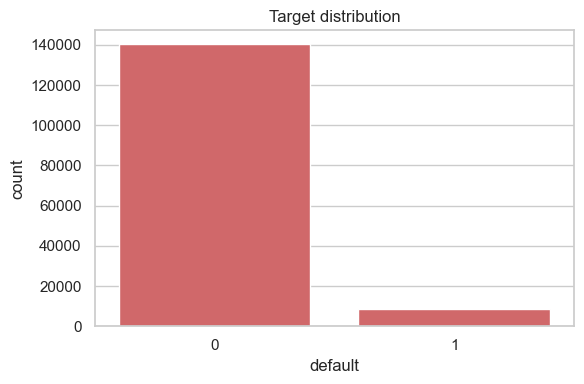

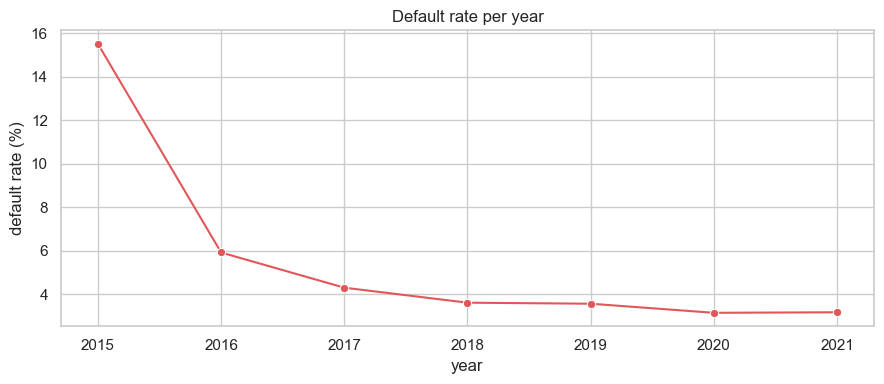

In [7]:
target_dist = (
    raw_df["default"].value_counts(dropna=False)
    .sort_index()
    .rename_axis("default")
    .reset_index(name="count")
)

default_rate_pct = raw_df["default"].mean(skipna=True) * 100

yearly_target = (
    raw_df.dropna(subset=["obs_date", "default"])
    .assign(year=lambda x: x["obs_date"].dt.year)
    .groupby("year", as_index=False)
    .agg(records=("default", "size"), defaults=("default", "sum"))
)
yearly_target["default_rate_pct"] = yearly_target["defaults"] / yearly_target["records"] * 100

display(target_dist)
print(f"Overall default rate: {default_rate_pct:.4f}%")
display(yearly_target)

if HAS_PLOTS:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=target_dist, x="default", y="count", color="#e15759")
    plt.title("Target distribution")
    plt.xlabel("default")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=yearly_target, x="year", y="default_rate_pct", marker="o", color="#e15759")
    plt.title("Default rate per year")
    plt.xlabel("year")
    plt.ylabel("default rate (%)")
    plt.tight_layout()
    plt.show()


## 7. Panel structure: unique companies, observations per company, temporal coverage

,metric,value
0,unique companies,46069.000000
1,min observations per company,1.000000
2,median observations per company,2.000000
3,max observations per company,26.000000
4,mean coverage days,826.936161
5,median coverage days,366.000000


,observations
count,46069.000000
mean,3.232738
std,1.886880
min,1.000000
25%,2.000000
50%,2.000000
75%,4.000000
max,26.000000


,first_obs,last_obs,coverage_days
count,46069,46069,46069.000000
mean,2017-03-29 13:25:05.906357,2019-07-04 11:53:10.214678,826.936161
min,2015-01-01 00:00:00,2015-01-28 00:00:00,0.000000
25%,2015-12-31 00:00:00,2017-12-31 00:00:00,365.000000
50%,2015-12-31 00:00:00,2019-12-31 00:00:00,366.000000
75%,2017-12-31 00:00:00,2020-12-31 00:00:00,1461.000000
max,2021-12-31 00:00:00,2021-12-31 00:00:00,2556.000000
std,NaN,NaN,689.830852


,year,records
0,2015,23092
1,2016,24995
2,2017,26153
3,2018,23864
4,2019,21659
5,2020,19137
6,2021,10029


,year,unique_companies
0,2015,23044
1,2016,24919
2,2017,26030
3,2018,23732
4,2019,21546
5,2020,19059
6,2021,9986


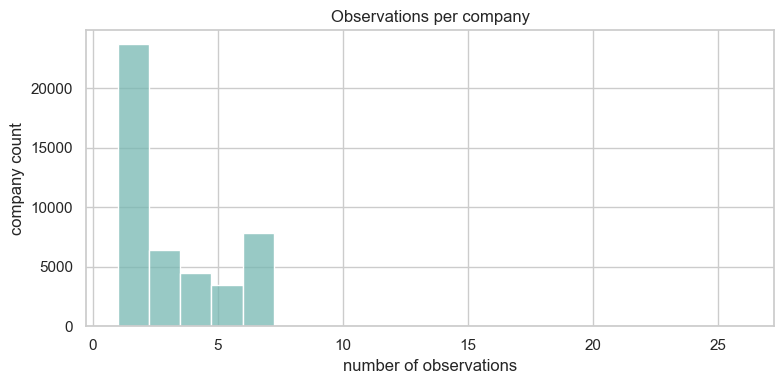

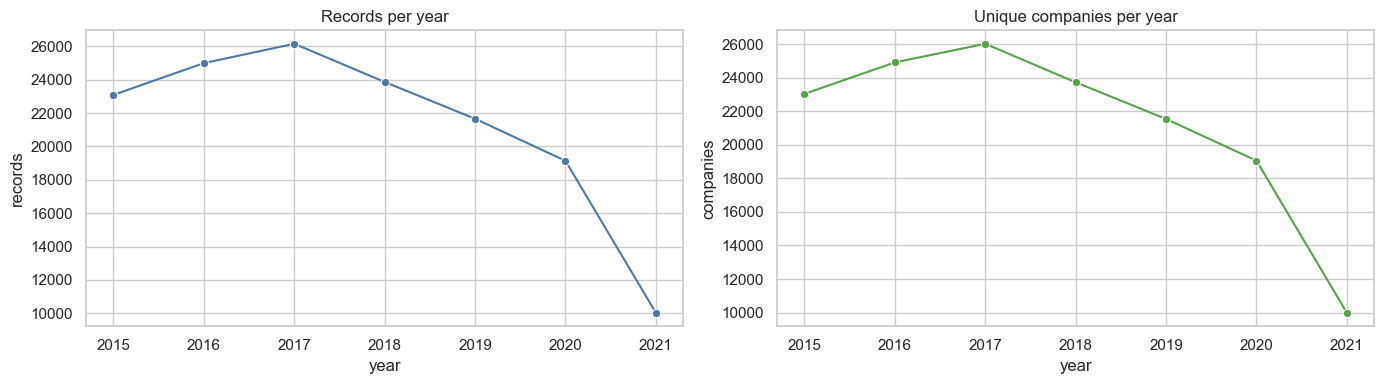

In [8]:
obs_per_company = raw_df.groupby("ID").size().rename("observations")

coverage = raw_df.groupby("ID")["obs_date"].agg(first_obs="min", last_obs="max")
coverage["coverage_days"] = (coverage["last_obs"] - coverage["first_obs"]).dt.days

panel_overview = pd.DataFrame(
    {
        "metric": [
            "unique companies",
            "min observations per company",
            "median observations per company",
            "max observations per company",
            "mean coverage days",
            "median coverage days",
        ],
        "value": [
            int(obs_per_company.shape[0]),
            int(obs_per_company.min()),
            float(obs_per_company.median()),
            int(obs_per_company.max()),
            float(coverage["coverage_days"].mean()),
            float(coverage["coverage_days"].median()),
        ],
    }
)

records_per_year = (
    raw_df.dropna(subset=["obs_date"])
    .assign(year=lambda x: x["obs_date"].dt.year)
    .groupby("year")
    .size()
    .rename("records")
    .reset_index()
)

companies_per_year = (
    raw_df.dropna(subset=["obs_date"])
    .assign(year=lambda x: x["obs_date"].dt.year)
    .groupby("year")["ID"]
    .nunique()
    .rename("unique_companies")
    .reset_index()
)

display(panel_overview)
display(obs_per_company.describe().to_frame(name="observations"))
display(coverage.describe())
display(records_per_year)
display(companies_per_year)

if HAS_PLOTS:
    plt.figure(figsize=(8, 4))
    sns.histplot(obs_per_company, bins=20, color="#76b7b2")
    plt.title("Observations per company")
    plt.xlabel("number of observations")
    plt.ylabel("company count")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=records_per_year, x="year", y="records", marker="o", ax=axes[0], color="#4e79a7")
    axes[0].set_title("Records per year")

    sns.lineplot(data=companies_per_year, x="year", y="unique_companies", marker="o", ax=axes[1], color="#59a14f")
    axes[1].set_title("Unique companies per year")

    for ax in axes:
        ax.set_xlabel("year")
    axes[0].set_ylabel("records")
    axes[1].set_ylabel("companies")

    plt.tight_layout()
    plt.show()


## 8. Outlier detection: boxplots and IQR / z-score metrics

,column,description,non_null,iqr_outlier_count,iqr_outlier_pct,zscore_outlier_count,zscore_outlier_pct
38,Var_39,Working Capital,148632,43931,29.556892,227,0.152726
21,Var_22,Net Profit,148921,38003,25.518899,207,0.139000
31,Var_32,Senior Net Debt,147616,36795,24.926160,342,0.231682
35,Var_36,Total Net Debt,147617,36618,24.806086,342,0.231681
23,Var_24,Profit Loss Before Tax,148918,36923,24.794182,208,0.139674
33,Var_34,Tangible Net Worth,148835,35122,23.597944,420,0.282192
9,Var_10,Eff Tang Net Worth Actual,148836,34973,23.497675,419,0.281518
7,Var_08,Earnings Before Interest And Tax,148915,34020,22.845247,191,0.128261
8,Var_09,Earnings Before Interest Tax And Depreciation,148917,30699,20.614839,206,0.138332
5,Var_06,Depreciation And Impairment,136640,27612,20.207845,164,0.120023


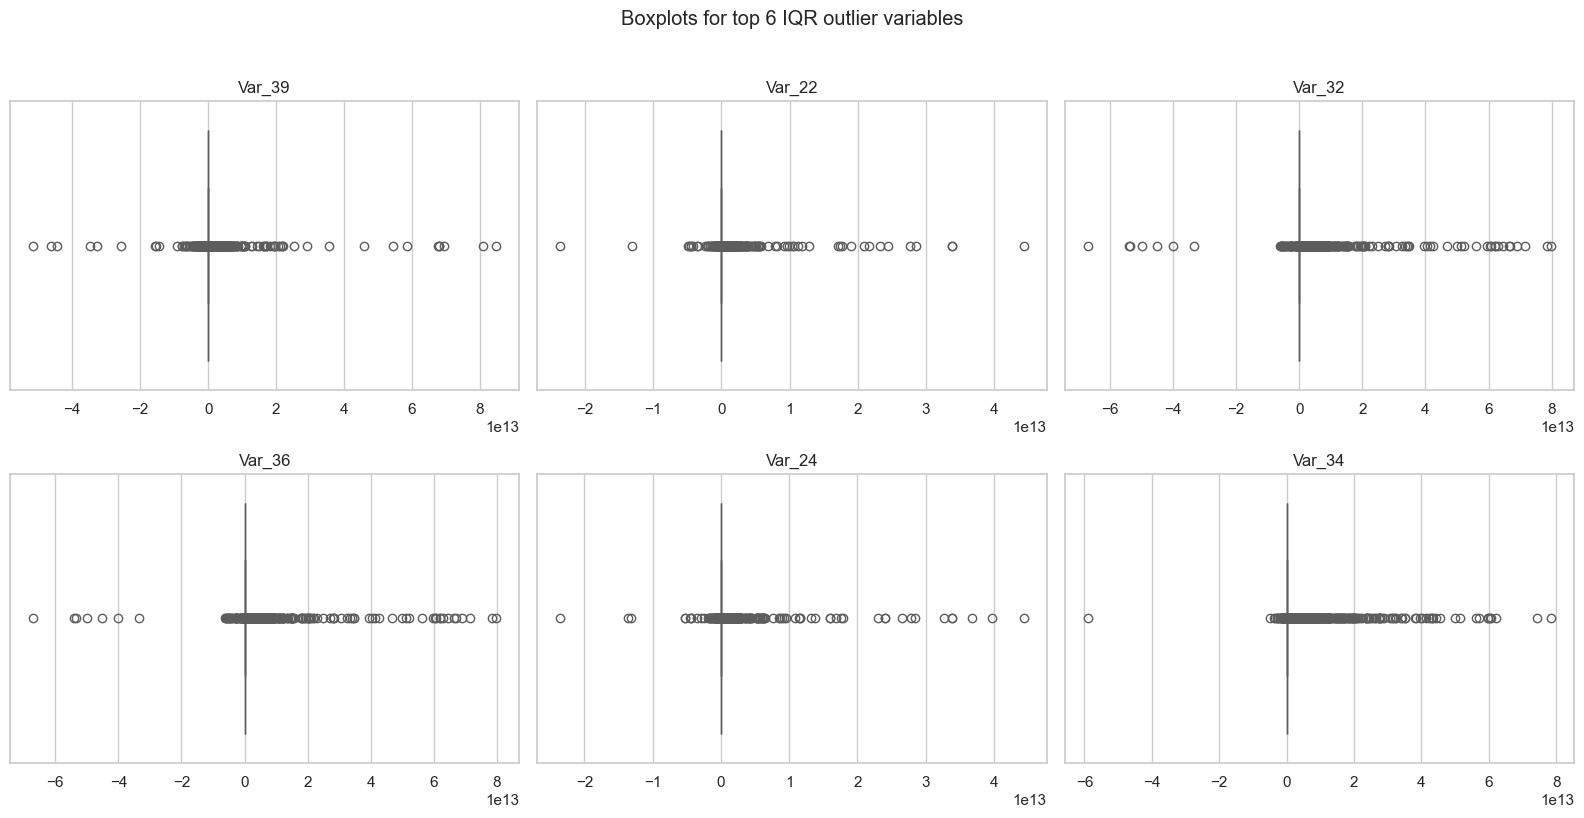

In [9]:
numeric_features = [c for c in var_cols if pd.api.types.is_numeric_dtype(raw_df[c])]


def iqr_outlier_count(series: pd.Series) -> int:
    s = series.dropna()
    if s.empty:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return 0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())


def zscore_outlier_count(series: pd.Series, threshold: float = 3.0) -> int:
    s = series.dropna()
    if s.empty:
        return 0
    std = s.std()
    if pd.isna(std) or std == 0:
        return 0
    z = ((s - s.mean()) / std).abs()
    return int((z > threshold).sum())


outlier_rows = []
for col in numeric_features:
    non_null = raw_df[col].notna().sum()
    iqr_count = iqr_outlier_count(raw_df[col])
    z_count = zscore_outlier_count(raw_df[col], threshold=3.0)
    outlier_rows.append(
        {
            "column": col,
            "description": descriptions.get(col, ""),
            "non_null": int(non_null),
            "iqr_outlier_count": int(iqr_count),
            "iqr_outlier_pct": (iqr_count / non_null * 100) if non_null else 0.0,
            "zscore_outlier_count": int(z_count),
            "zscore_outlier_pct": (z_count / non_null * 100) if non_null else 0.0,
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_outlier_pct", ascending=False)
display(outlier_summary)

if HAS_PLOTS:
    selected_cols = outlier_summary.head(6)["column"].tolist()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for ax, col in zip(axes.flatten(), selected_cols):
        sns.boxplot(x=raw_df[col], ax=ax, color="#edc948")
        ax.set_title(col)
        ax.set_xlabel("")

    for ax in axes.flatten()[len(selected_cols):]:
        ax.axis("off")

    plt.suptitle("Boxplots for top 6 IQR outlier variables", y=1.02)
    plt.tight_layout()
    plt.show()


## 9. Data cleaning: remove post-default rows, missingness flags, median impute

In [ ]:
panel = raw_df.sort_values(["ID", "obs_date"]).copy()

first_default_by_company = (
    panel.loc[panel["default"] == 1]
    .groupby("ID")["obs_date"]
    .min()
    .rename("first_default_date")
)

panel = panel.join(first_default_by_company, on="ID")

cleaned = panel[
    panel["first_default_date"].isna() | (panel["obs_date"] <= panel["first_default_date"])
].copy()

rows_removed_post_default = int(len(panel) - len(cleaned))

missing_before = cleaned[var_cols].isna().mean() * 100

cols_with_missing = [c for c in var_cols if cleaned[c].isna().any()]
for col in cols_with_missing:
    cleaned[f"{col}_missing_flag"] = cleaned[col].isna().astype("int8")

median_values = cleaned[var_cols].median(numeric_only=True)
cleaned[var_cols] = cleaned[var_cols].fillna(median_values)

missing_after = cleaned[var_cols].isna().mean() * 100

cleaned = cleaned.drop(columns=["first_default_date"])

flag_rename = {
    f"{col}_missing_flag": f"{renamed_columns.get(col, col)} - missing flag"
    for col in cols_with_missing
}

cleaned_renamed = cleaned.rename(columns={**renamed_columns, **flag_rename})

cleaned_output = PROCESSING_DIR / "cleaned_panel_imputed.csv"
cleaned_renamed_output = PROCESSING_DIR / "cleaned_panel_imputed_with_descriptions.csv"
cleaned.to_csv(cleaned_output, sep=";", index=False)
cleaned_renamed.to_csv(cleaned_renamed_output, sep=";", index=False)

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "rows before cleaning",
            "rows after removing post-default",
            "rows removed post-default",
            "columns with missingness flagged",
            "rows in final cleaned dataset",
            "columns in final cleaned dataset",
        ],
        "value": [
            len(raw_df),
            len(panel) - rows_removed_post_default,
            rows_removed_post_default,
            len(cols_with_missing),
            len(cleaned),
            cleaned.shape[1],
        ],
    }
)

missing_compare = pd.DataFrame(
    {
        "column": var_cols,
        "missing_pct_before": missing_before.values,
        "missing_pct_after": missing_after.values,
    }
).sort_values("missing_pct_before", ascending=False)

display(cleaning_summary)
display(missing_compare)
print(f"Saved: {cleaned_output}")
print(f"Saved: {cleaned_renamed_output}")

if HAS_PLOTS:
    top_missing_compare = missing_compare.head(20)

    plt.figure(figsize=(12, 7))
    plt.barh(top_missing_compare["column"], top_missing_compare["missing_pct_before"], label="before", alpha=0.8)
    plt.barh(top_missing_compare["column"], top_missing_compare["missing_pct_after"], label="after", alpha=0.8)
    plt.title("Missingness before vs after cleaning (top 20)")
    plt.xlabel("missing %")
    plt.ylabel("column")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Outputs (Context)

Folder routing for this notebook:
- `data/raw/`: raw input sources read by this notebook.
- `data/processing/`: processed datasets written by this notebook.
- `data/logs/` and `data/final/`: reserved for downstream notebooks.

Files produced in `data/processing/`:
- `merged_all.csv`: row-wise concatenation of all raw CSV panels.
- `merged_all_with_descriptions.csv`: same data with human-readable column names.
- `cleaned_panel_imputed.csv`: modeling-ready cleaned panel after post-default trimming and median imputation.
- `cleaned_panel_imputed_with_descriptions.csv`: cleaned panel with readable column names.
